In [1]:
%pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: D:\flyrank\.venv\Scripts\python.exe -m pip install --upgrade pip


# Ranking Signal Analysis: explainable content-review priorities

Hamza Afzal · 9 October 2026 · Machine Learning capstone

**Scope:** completed, reproducible local starter study. Full warehouse analysis, intern validation and portal submission are pending. The public source repository and deployed paper are verified. The attached brief points to the full warehouse; the lane guide allows starter analysis. This notebook documents the distinction so the starter results cannot be mistaken for full-release results.

## Abstract

This study asks whether safe content and contemporaneous search signals can prioritize review of pages associated with observed impression decline on clients held out from training. It uses 30,000 starter content items across 32 pseudonymized clients, with a current-window decline bucket as a proxy. A transparent training-fitted rule, logistic regression and a conservative random forest are compared using client-grouped training, validation and test partitions. The validation-selected logistic regression achieved held-out average precision 0.677 versus 0.598 for the rule, with precision@50 0.800 versus 0.420. The signal audit and reason-coded queue support human inspection and do not establish future decline prediction or causal editorial benefit.

## 1. Question and introduction

An editor has a limited review budget and needs an evidence-based starting list. The unit is a page, and the action is inspection before any content change. Which safe signals are associated with the current decline proxy across clients, and does their combination improve top-50 review discrimination over an explainable rule? Wasted review time and delayed attention are the error costs. The queue never automatically edits, merges or prunes content. The professional demonstration is a reproducible backend-compatible analysis pipeline, while the editorial decision remains the research focus.

In [2]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image
candidate = Path.cwd().resolve()
ROOT = next((path for path in [candidate, *candidate.parents]
             if (path / "data/raw/content_refresh_anonymized.csv").exists()), None)
if ROOT is None:
    own_repo = "https://github.com/Hamza2-2/flyrank-ai-internship"
    clone_root = candidate / "flyrank-ai-internship"
    if not clone_root.exists():
        subprocess.run(["git", "clone", "--depth", "1", own_repo, str(clone_root)],
                       check=True, capture_output=True, text=True)
    if not (clone_root / "data/raw/content_refresh_anonymized.csv").exists():
        raise FileNotFoundError("The owned repository checkout has no starter CSV; verify the public repository and rerun.")
    ROOT = clone_root.resolve()
sys.path.insert(0, str(ROOT / "work/scripts"))
from capstone_analysis import load_data, FEATURES, BANNED, run_study
study = run_study()
print('Local pipeline regenerated aggregate evidence and charts.')

{
  "rows": 30000,
  "selected_model": "logistic_regression",
  "test_metrics": {
    "rule_baseline": {
      "rows": 4135,
      "base_rate": 0.5956469165659009,
      "majority_class_accuracy": 0.5956469165659009,
      "both_classes_observed": true,
      "roc_auc": 0.5295529336573634,
      "average_precision": 0.5976280255977686,
      "precision_at_50": 0.42,
      "effective_k_at_50": 50,
      "lift_at_50_vs_base_rate": 0.705115712545676,
      "precision_at_100": 0.48,
      "effective_k_at_100": 100,
      "lift_at_100_vs_base_rate": 0.8058465286236297,
      "precision_at_250": 0.516,
      "effective_k_at_250": 250,
      "lift_at_250_vs_base_rate": 0.8662850182704019
    },
    "logistic_regression": {
      "rows": 4135,
      "base_rate": 0.5956469165659009,
      "majority_class_accuracy": 0.5956469165659009,
      "both_classes_observed": true,
      "roc_auc": 0.5972194701680567,
      "average_precision": 0.676731450879442,
      "precision_at_50": 0.8,
      "effec

## 2. Data and safety

The bundled `data/raw/content_refresh_anonymized.csv` has one content item per row and trailing-90-day aggregates. The starter dictionary does not specify an exact calendar end date, so no warehouse date window is assigned to it. Eligibility requires positive impressions and content age at least 90 days. Grain and duplicate checks run before modeling. IDs are used locally for joins/splits, never as features; public outputs show aggregate statistics and synthetic review-case labels. The small local case-to-pseudonym lookup CSV is ignored by git. No raw warehouse export, names, domains, URLs, queries or credentials are published.

Position zero becomes missing measurement; missing keyword/depth/scroll observations receive explicit flags. Median imputation is fitted on training only, and rates retain their documented percentage units. Scroll rates above 100 are not silently clipped, because measurement systems differ. Provider/model names, redundant derived tiers and all last/previous-30-day trend inputs are excluded. No full-warehouse facts have been queried.

In [3]:
display(pd.DataFrame([study['data']]).T.rename(columns={0:'measured value'}))
display(pd.DataFrame(study['split']).T)
print('Model columns:', study['feature_columns'])

,measured value
rows,30000
columns,44
clients,32
eligible_rows,30000
declining_rows,16262
declining_share,0.542067
stale_visible_rows,17
visible_rows_500,16726
no_position_rows,1205
missing_word_count_rows,7699


,rows,clients,proxy_base_rate
train,24099.0,18.0,0.538197
validation,1766.0,6.0,0.469422
test,4135.0,8.0,0.595647


Model columns: ['search_volume', 'competition', 'cpc', 'word_count', 'log_impressions_90d', 'log_clicks_90d', 'log_sessions_90d', 'days_with_impressions', 'days_with_sessions', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'has_keyword_data', 'has_word_count', 'has_position', 'has_scroll_measurement', 'content_type', 'competition_level', 'main_intent']


## 3. Methodology, baseline and leakage audit

**Proxy:** `trend_direction == down`, defined by a measured decline beyond 20% between two current 30-day impression windows. This is not a future target or an editor-utility label. All six window components and both trend columns are banned as features.

**Rule fixed before fitting:** 40% visibility, 30% freshness, 25% visibility-adjusted position opportunity, and 5% visibility-adjusted depth gap. Visibility, freshness and depth use empirical cumulative distributions fitted on training clients for validation and development clients for final testing. Missing depth and missing position add no opportunity bonus. The rule uses no target field.

**Models fixed before test:** logistic regression (C=1, 1,500 iterations) and 180-tree forest (depth 10, leaf floor 25, square-root feature subsampling). Numeric imputation, scaling for logistic regression, and categorical encoding are fitted within each training pipeline. No hyperparameter search uses test outcomes. The model with highest validation average precision is selected, then refitted on training plus validation.

**Validation:** 25% of clients held out for test (seed 2026), and 25% of remaining clients for validation (seed 2027). Client sets cannot overlap. Both baseline and models see identical partitions. Client-bootstrap intervals use 400 draws and preserve within-client dependence, but eight test clusters limit precision. A shuffled-training-label control is evaluated only on validation. Validation permutation importance and a fixed metadata-only ablation audit where association comes from. Rerunning the notebook reproduces the same held-out result; it is not fresh independent confirmation.

In [4]:
display(pd.DataFrame(study['validation_metrics']).T)
print('Selected by validation AP:', study['selected_model'])
print(json.dumps(study['leakage_audit'], indent=2))

,rows,base_rate,majority_class_accuracy,both_classes_observed,roc_auc,average_precision,precision_at_50,effective_k_at_50,lift_at_50_vs_base_rate,precision_at_100,effective_k_at_100,lift_at_100_vs_base_rate,precision_at_250,effective_k_at_250,lift_at_250_vs_base_rate
rule_baseline,1766,0.469422,0.530578,True,0.737145,0.599673,0.42,50,0.894717,0.42,100,0.894717,0.544,250,1.158871
logistic_regression,1766,0.469422,0.530578,True,0.825535,0.751948,0.88,50,1.874644,0.84,100,1.789433,0.768,250,1.636053
random_forest,1766,0.469422,0.530578,True,0.828775,0.747466,0.88,50,1.874644,0.79,100,1.682919,0.768,250,1.636053


Selected by validation AP: logistic_regression
{
  "ids_excluded_from_features": true,
  "trend_fields_excluded": true,
  "all_six_30_day_trend_input_fields_excluded": true,
  "client_overlap_between_partitions": 0,
  "imputation_scaling_encoding_fitted_on_train": true,
  "final_refit_scope": "train plus validation clients, never test clients",
  "baseline_empirical_cdfs_fit_scope": "development clients for final test; training clients for validation",
  "label_shuffling_control": {
    "split": "validation only",
    "rows": 1766,
    "base_rate": 0.4694224235560589,
    "majority_class_accuracy": 0.5305775764439411,
    "both_classes_observed": true,
    "roc_auc": 0.30222342949613334,
    "average_precision": 0.3705820625705636,
    "precision_at_50": 0.62,
    "effective_k_at_50": 50,
    "lift_at_50_vs_base_rate": 1.3207720144752715,
    "precision_at_100": 0.33,
    "effective_k_at_100": 100,
    "lift_at_100_vs_base_rate": 0.7029915560916767,
    "precision_at_250": 0.164,
    "

## 4. Results: model and baseline on the same split

Average precision is evaluated beside the proxy base rate; precision@50 is tied to an explicit review budget. The operational subset uses at least 500 impressions, and its model and baseline metrics are reported separately on the same subset. The rule score is not claimed to be a calibrated probability. Model outputs are used as ranking scores; calibration to future editorial value has not been established.

,rows,base_rate,majority_class_accuracy,both_classes_observed,roc_auc,average_precision,precision_at_50,effective_k_at_50,lift_at_50_vs_base_rate,precision_at_100,effective_k_at_100,lift_at_100_vs_base_rate,precision_at_250,effective_k_at_250,lift_at_250_vs_base_rate
rule_baseline,4135,0.595647,0.595647,True,0.529553,0.597628,0.42,50,0.705116,0.48,100,0.805847,0.516,250,0.866285
logistic_regression,4135,0.595647,0.595647,True,0.597219,0.676731,0.8,50,1.343078,0.77,100,1.292712,0.744,250,1.249062
random_forest,4135,0.595647,0.595647,True,0.637876,0.689711,0.72,50,1.20877,0.74,100,1.242347,0.74,250,1.242347


,rows,base_rate,majority_class_accuracy,both_classes_observed,roc_auc,average_precision,precision_at_50,effective_k_at_50,lift_at_50_vs_base_rate,precision_at_100,effective_k_at_100,lift_at_100_vs_base_rate,precision_at_250,effective_k_at_250,lift_at_250_vs_base_rate
rule_baseline,1177,0.598131,0.598131,True,0.432275,0.547369,0.42,50,0.702188,0.48,100,0.8025,0.516,250,0.862688
logistic_regression,1177,0.598131,0.598131,True,0.605633,0.681033,0.72,50,1.20375,0.73,100,1.220469,0.7,250,1.170313
random_forest,1177,0.598131,0.598131,True,0.652214,0.710569,0.78,50,1.304063,0.79,100,1.320781,0.764,250,1.277313


{
  "resamples": 400,
  "clusters": 8,
  "seed": 2026,
  "method": "resample held-out clients with replacement, retaining all their rows; percentile interval",
  "limitation": "only eight held-out client clusters; intervals do not establish future or causal performance",
  "average_precision_difference": {
    "lower_95": 0.039503477795848466,
    "upper_95": 0.13975101017368496
  },
  "precision_at_50_difference": {
    "lower_95": 0.23950000000000002,
    "upper_95": 0.54
  }
}


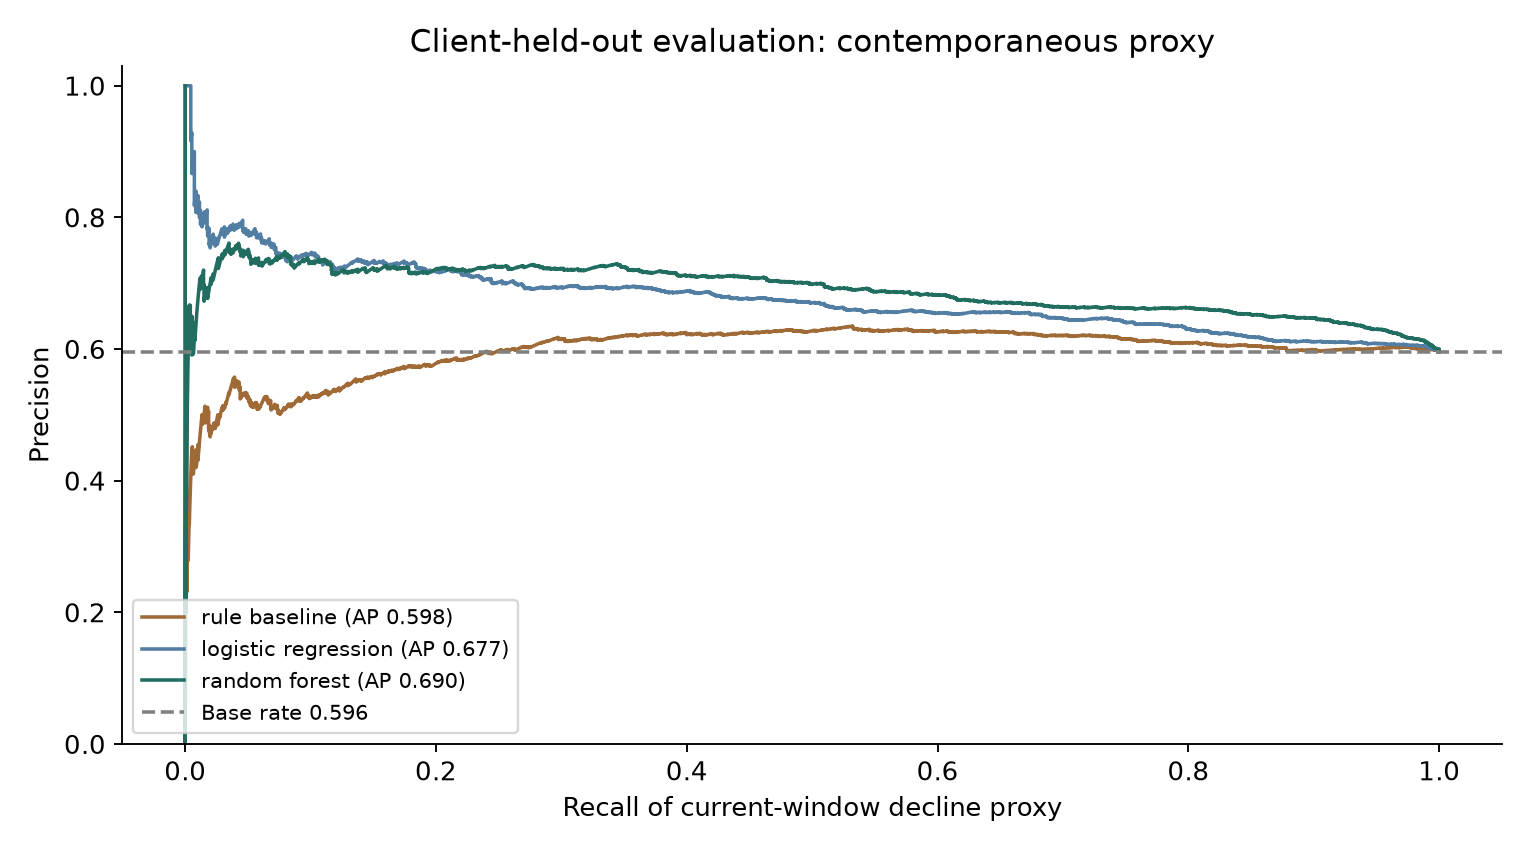

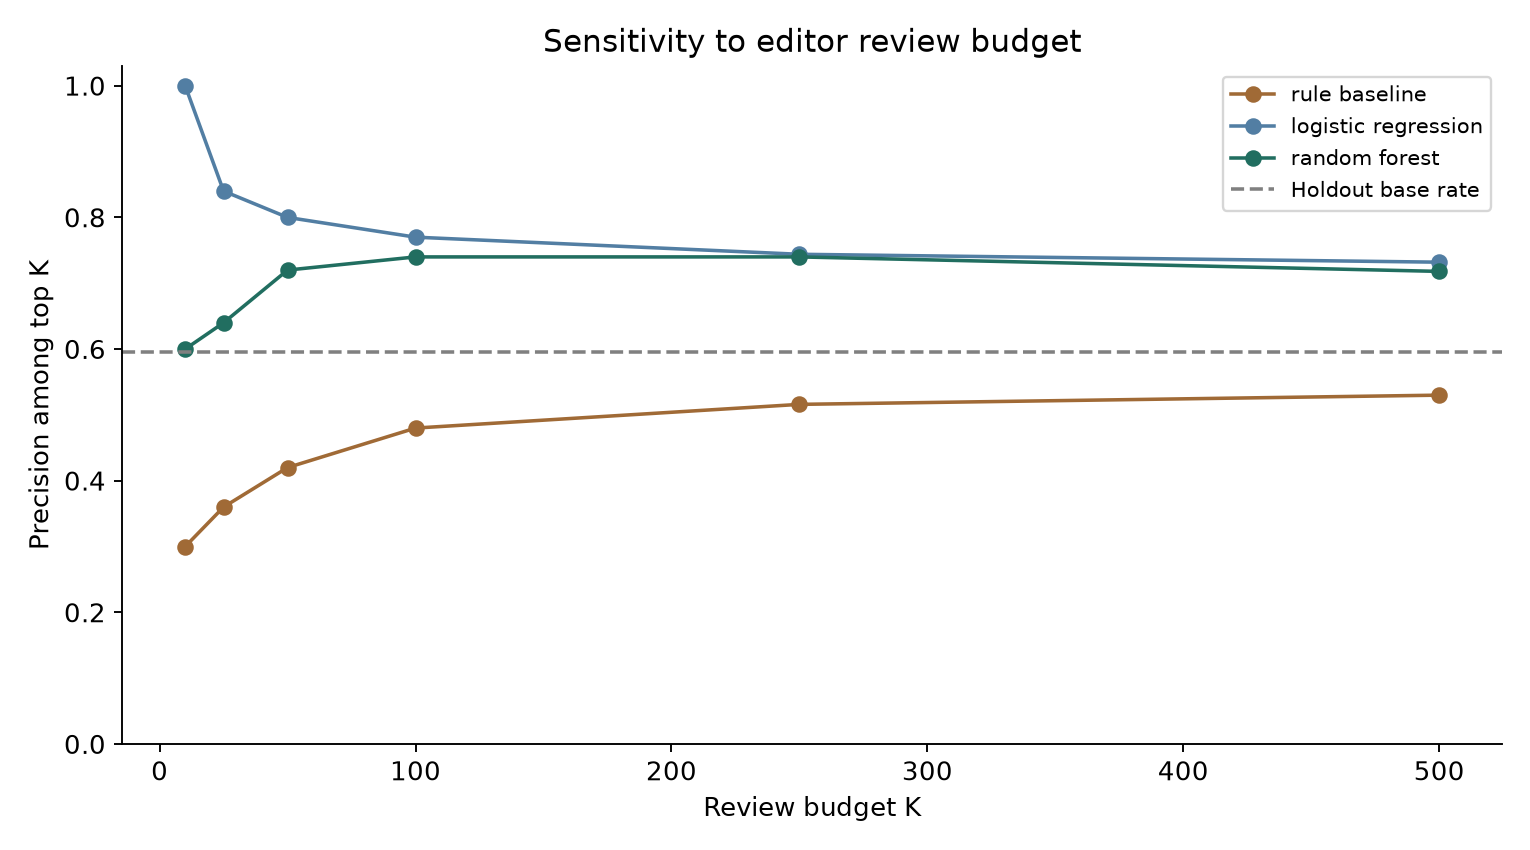

In [5]:
display(pd.DataFrame(study['test_metrics']).T)
display(pd.DataFrame(study['review_eligible_test_metrics']).T)
print(json.dumps(study['client_bootstrap_intervals'], indent=2))
display(Image(filename=str(ROOT/'work/figures/capstone_precision_recall.png')))
display(Image(filename=str(ROOT/'work/figures/capstone_review_budget.png')))

## 5. Interpretation and error analysis

Permutation importance measures association in the validation sample, conditional on this model and its correlated feature set; it is not a causal ranking-factor estimate. The metadata-only ablation excludes all traffic totals, day-coverage variables and rates. Per-client and missingness strata reveal whether a global result conceals uneven behavior. A proxy-negative top-ranked item is not proved to be wasted editorial effort, and a proxy-positive item is not proved to benefit from editing.

,feature,ap_drop_mean,ap_drop_std
5,log_clicks_90d,0.113032,0.005239
4,log_impressions_90d,0.082235,0.007851
17,has_position,0.074012,0.014919
15,has_keyword_data,0.041339,0.003849
20,competition_level,0.027875,0.007374
9,content_age_days,0.015542,0.003444
6,log_sessions_90d,0.008480,0.003743
12,avg_position,0.007094,0.005128
21,main_intent,0.007052,0.003266
14,scroll_rate,0.006961,0.004215


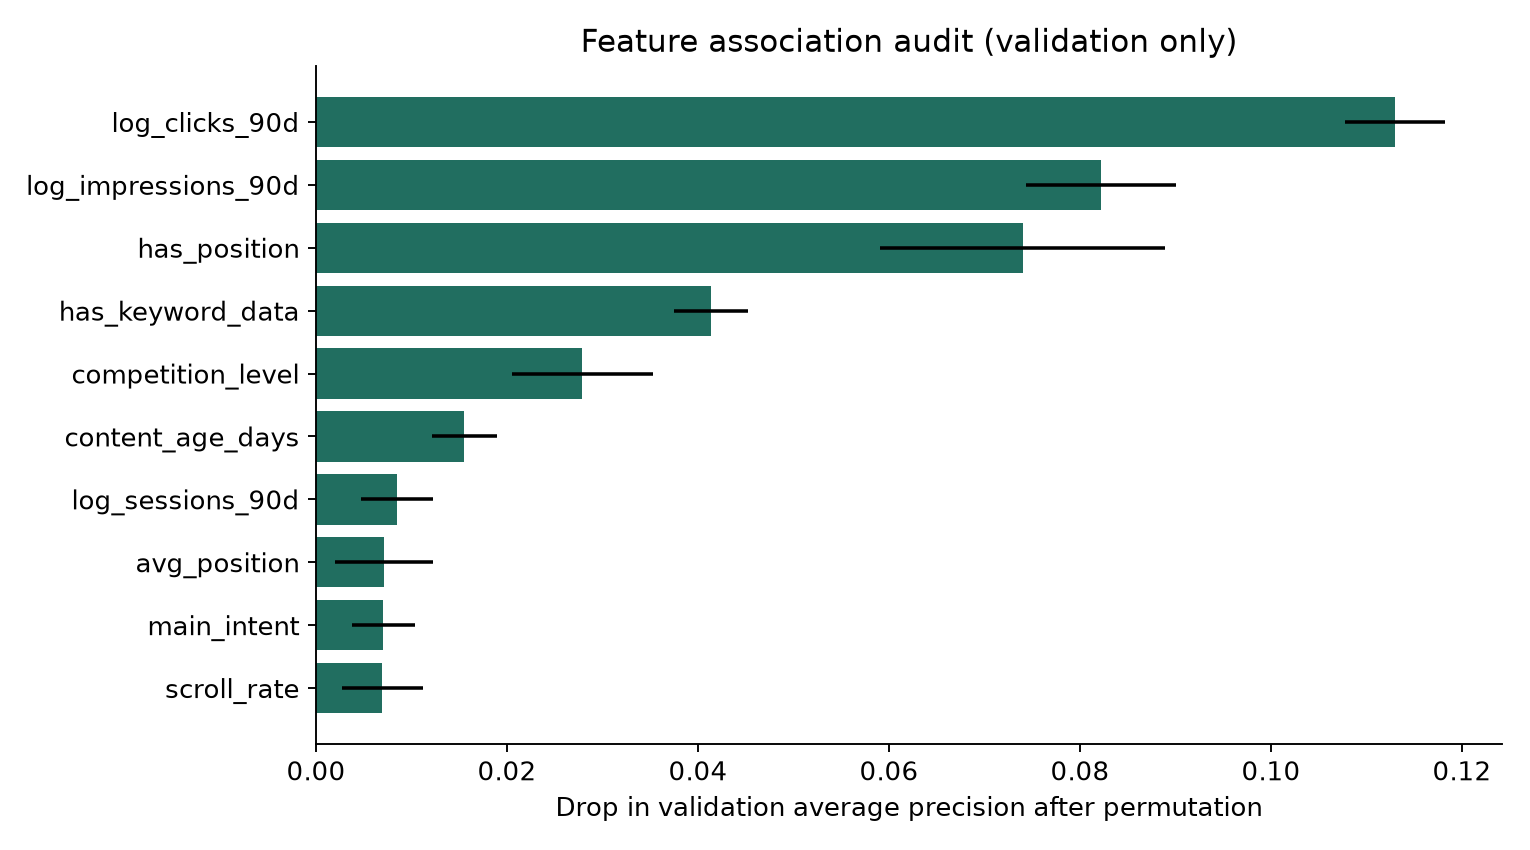

,group,rows,base_rate,model_ap,baseline_ap,model_roc_auc,baseline_roc_auc
0,Held-out group 1,87,0.517241,0.762025,0.613250,0.803704,0.623810
1,Held-out group 2,556,0.595324,0.680874,0.612280,0.626156,0.558980
2,Held-out group 3,32,0.531250,0.772900,0.472544,0.686275,0.431373
3,Held-out group 4,578,0.669550,0.858987,0.728174,0.739194,0.531786
4,Held-out group 5,1171,0.667805,0.794245,0.705225,0.666300,0.606713
5,Held-out group 6,254,0.385827,0.499278,0.524829,0.567831,0.697737
6,Held-out group 7,505,0.548515,0.697358,0.477850,0.688169,0.428020
7,Held-out group 8,952,0.552521,0.638789,0.582764,0.594780,0.553781


,stratum,rows,base_rate,majority_class_accuracy,both_classes_observed,roc_auc,average_precision,precision_at_50,effective_k_at_50,lift_at_50_vs_base_rate,precision_at_100,effective_k_at_100,lift_at_100_vs_base_rate,precision_at_250,effective_k_at_250,lift_at_250_vs_base_rate
0,position unavailable,20,0.000000,1.000000,False,NaN,NaN,0.00,20,NaN,0.00,20,NaN,0.000000,20,NaN
1,word count missing,226,0.517699,0.517699,True,0.622363,0.636225,0.64,50,1.236239,0.62,100,1.197607,0.517699,226,1.000000
2,word count observed,3909,0.600153,0.600153,True,0.594981,0.679355,0.80,50,1.332992,0.77,100,1.283005,0.744000,250,1.239683
3,impressions below 500,2958,0.594659,0.594659,True,0.596030,0.679782,0.84,50,1.412575,0.80,100,1.345310,0.776000,250,1.304951
4,impressions at least 500,1177,0.598131,0.598131,True,0.605633,0.681033,0.72,50,1.203750,0.73,100,1.220469,0.700000,250,1.170313


{
  "numeric_features": [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "has_keyword_data",
    "has_word_count"
  ],
  "categorical_features": [
    "content_type",
    "competition_level",
    "main_intent"
  ],
  "metrics": {
    "rows": 4135,
    "base_rate": 0.5956469165659009,
    "majority_class_accuracy": 0.5956469165659009,
    "both_classes_observed": true,
    "roc_auc": 0.48278456563843447,
    "average_precision": 0.5721974003993616,
    "precision_at_50": 0.46,
    "effective_k_at_50": 50,
    "lift_at_50_vs_base_rate": 0.7722695899309785,
    "precision_at_100": 0.5,
    "effective_k_at_100": 100,
    "lift_at_100_vs_base_rate": 0.8394234673162809,
    "precision_at_250": 0.544,
    "effective_k_at_250": 250,
    "lift_at_250_vs_base_rate": 0.9132927324401138
  },
  "interpretation": "removes contemporaneous traffic totals, coverage and rates; still observational metadata, not a prospective 

In [6]:
audit = json.loads((ROOT/'work/outputs/capstone_feature_audit.json').read_text(encoding='utf-8'))
display(pd.DataFrame(audit).sort_values('ap_drop_mean', ascending=False).head(10))
display(Image(filename=str(ROOT/'work/figures/capstone_feature_audit.png')))
display(pd.DataFrame(study['per_client_metrics']))
display(pd.DataFrame(study['subgroup_metrics']))
print(json.dumps(study['metadata_only_ablation'], indent=2))
print(json.dumps(study['error_analysis'], indent=2))

## 6. Ranked recommendations and action playbook

Eligible held-out starter cases (at least 500 impressions) are ordered by the selected model's current-proxy score. Actions and reason codes use observable context; target labels never enter action generation. Missing position triggers an instrumentation check; low CTR at a measured position up to 20 triggers metadata/intent review; limited depth triggers coverage review; stale content triggers factual checking; other cases trigger monitoring. For the first 20, an editor should confirm measurement, inspect the real content in an authorized system, record accept/reject and reasoning, and edit only after that review. Those content checks cannot be completed from an anonymized numerical export. This bounded queue demonstrates an actionable interface without publishing identifying rows. The ignored local lookup supports authorized joins to pseudonymized pages.

,rank,case,review_score,action,reason_codes
0,1,Review case R01,0.9412,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."
1,2,Review case R02,0.9092,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."
2,3,Review case R03,0.9024,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."
3,4,Review case R04,0.9008,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."
4,5,Review case R05,0.8955,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."
5,6,Review case R06,0.8946,Inspect current search evidence and monitor,[model_associated_with_current_decline_proxy]
6,7,Review case R07,0.8940,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."
7,8,Review case R08,0.8930,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."
8,9,Review case R09,0.8851,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."
9,10,Review case R10,0.8847,"Review title, description and query intent","[low_ctr_review, model_associated_with_current..."


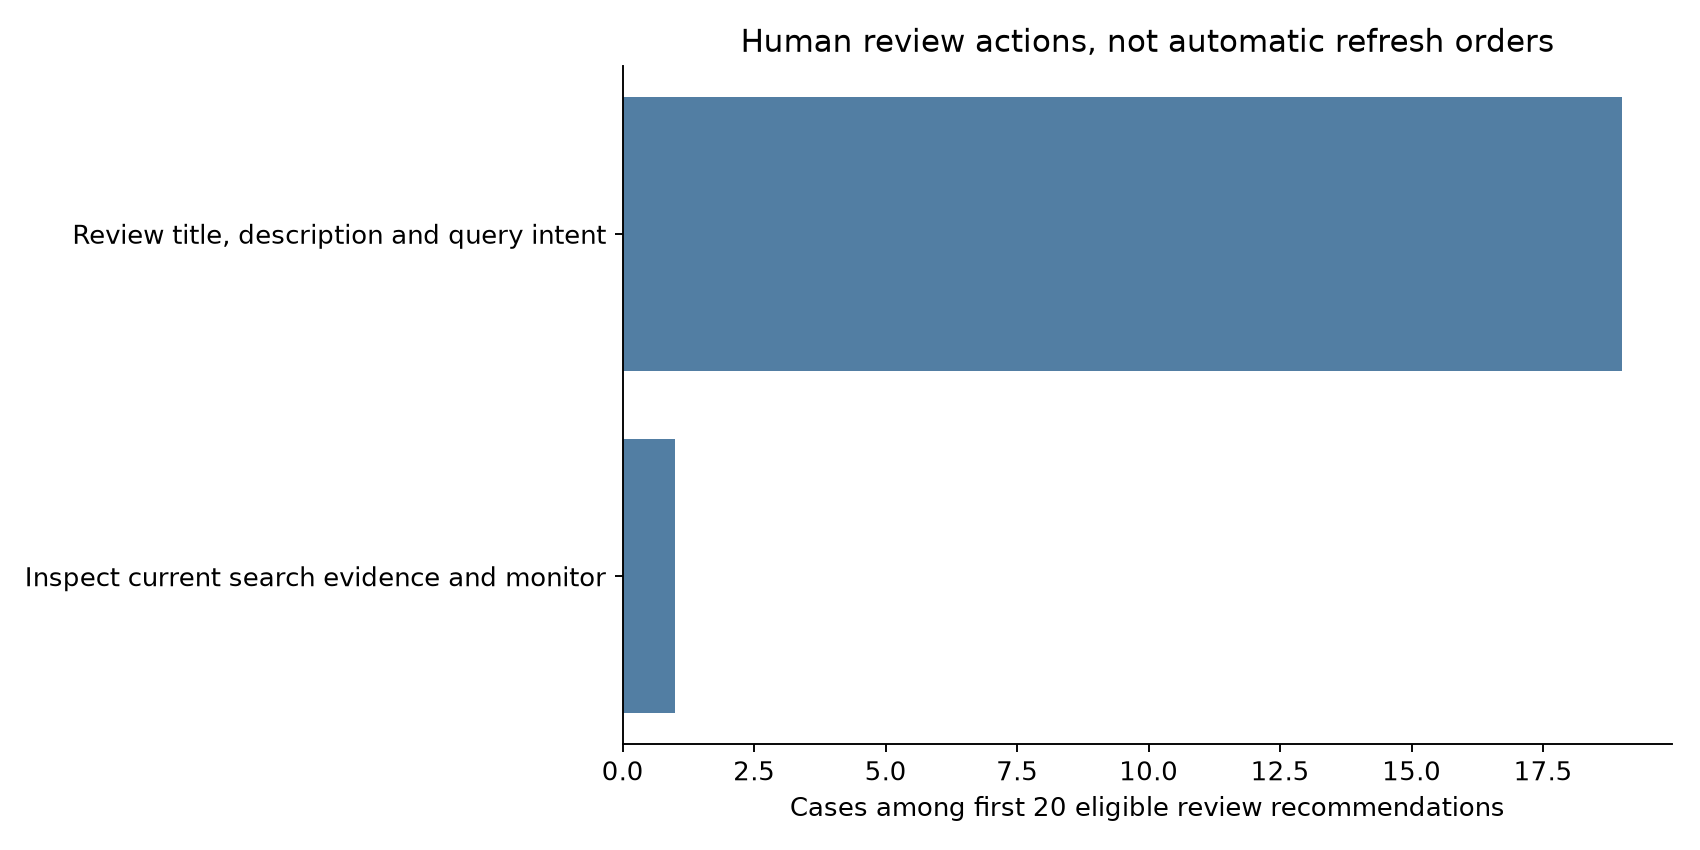

In [7]:
queue = json.loads((ROOT/'work/outputs/capstone_ranked_actions.json').read_text(encoding='utf-8'))
display(pd.DataFrame(queue['recommendations'])[['rank','case','review_score','action','reason_codes']])
display(Image(filename=str(ROOT/'work/figures/capstone_actions.png')))

## 7. Limitations and honest framing

The feature totals and rates overlap the same window as the proxy label. Excluding direct trend fields prevents direct reconstruction, but does not create a future prediction task. The label is a thresholded observed measurement, not editorial utility. The sample contains older pages with impressions and only 32 clients; it may underrepresent new/invisible content and the larger warehouse. Missingness follows content type. Eight held-out clients make subgroup conclusions and bootstrap intervals tentative. Instrumentation differences and seasonality can explain apparent decline. No content text, query intent, intervention records or editorial review outcomes are available. Model scores are not calibrated causal impact probabilities.

**Pending to satisfy the strict full-release brief:** approve Hugging Face access, supply a read token locally, inspect the release manifest and grains, build nonoverlapping historical features and a later observed outcome, and rerun client/time-aware validation. Develop query logic in March 2026 rather than the final-month sample, respect three-valued availability flags, and scan the full release once after query validation. The warehouse plan in the capstone task folder specifies this extension; no future metrics are fabricated.

In [8]:
print('Pending requirements:')
for requirement in study['pending_requirements']:
    print('-', requirement)

Pending requirements:
- approved Hugging Face access and local HF_TOKEN
- full warehouse feature and future-outcome construction
- client/time-aware warehouse evaluation
- intern/editor review
- actual internship portal submission after review


## 8. Reproducibility and artifact links

From a fresh clone, install repository requirements plus `nbformat`, `nbclient`, and `ipykernel`; run `python work/scripts/capstone_analysis.py`, then execute this notebook top to bottom. The notebook calls the same script and saves deterministic aggregate JSON and four chart PNGs. Seed 2026 and the source SHA-256 are in the metrics file; seed 2027 makes the validation partition. Exact package versions are recorded below. Reference `scripts/` and data remain unchanged.

Artifacts: [metrics](../outputs/capstone_metrics.json), [feature audit](../outputs/capstone_feature_audit.json), [ranked actions](../outputs/capstone_ranked_actions.json), [reproducible analysis](../scripts/capstone_analysis.py), [report](../capstone_report.md). The verified [public repository](https://github.com/Hamza2-2/flyrank-ai-internship) and [paper](https://hamza2-2.github.io/flyrank-ai-internship/) are recorded in the root submission metadata. The completed local paper must retain all nine required sections and data credit.

In [9]:
print(json.dumps(study['environment'], indent=2))
print('Source SHA-256:', study['data']['source_sha256'])
assert all(count['clients'] > 0 for count in study['split'].values())
assert study['leakage_audit']['client_overlap_between_partitions'] == 0
assert all((ROOT/'work/figures'/name).exists() for name in [
    'capstone_precision_recall.png','capstone_review_budget.png',
    'capstone_feature_audit.png','capstone_actions.png'])
print('Aggregate outputs and four research figures verified.')

{
  "numpy": "2.4.6",
  "pandas": "3.0.6",
  "scikit-learn": "1.9.1",
  "matplotlib": "3.11.2"
}
Source SHA-256: c43bdac4eccfa17fcd8a33974fe36f2c998c03a3ae3af8d80cf712abab5d6396
Aggregate outputs and four research figures verified.


## 9. Acknowledgments and data credit

[Built on the FlyRank ML Internship dataset](https://flyrank.ai). Dataset semantics and starter workflow are documented in the supplied FlyRank repository. The baseline adapts the reference weights while fitting transformations within development groups. AI assistance supported code and writing; Hamza Afzal must validate the outputs, decisions and explanations before submission.

## Demo outline, social draft and employer summary

**Five-minute demo:** 0:00–0:45 name the editor decision and current-proxy limitation; 0:45–1:30 show the 30,000-row safety/grain checks; 1:30–2:30 show grouped validation and the fair baseline/model table; 2:30–3:30 interpret the validation feature audit and metadata ablation; 3:30–4:30 inspect the reason-coded review queue; 4:30–5:00 state what the study cannot prove and the warehouse/deployment requirements.

**Social-post draft (publish only after validation/deployment):** I built a reproducible Ranking Signal Analysis study on the FlyRank starter dataset, with client-held-out evaluation, a transparent rule, model comparisons and explainable content-review suggestions. The measured result describes current-window associations; it does not claim future decline prediction or causal refresh impact. Notebook, paper and source links will be added after publication.

**Employer-facing summary:** This project demonstrates a repeatable Python analysis pipeline with explicit data contracts, group validation and inspectable JSON outputs. It compares learned signals with a transparent rule and turns them into bounded recommendations for human review. The documented limits distinguish reproducible starter findings from an unexecuted warehouse extension.

## Final self-check

- [x] All paper sections, figures, evidence and data credit authored.
- [x] Notebook executes top to bottom and regenerates results.
- [x] No private row export, client identifiers, credentials or causal claims.
- [x] Model and baseline evaluated on the same group partitions.
- [ ] Intern validates the scientific framing and first 20 editorial cases.
- [ ] Full-warehouse extension completes the strict brief's data requirement.
- [x] Owned public repo and deployed paper URL verified.
- [ ] Portal submission by Hamza after personal review.

These pending items are not marked complete by local execution.